In [13]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from doc_utils import DirectoryManager
import fusi_utils as utils
import h5py

In [14]:
base_path = Path(
    "/Users/clairenastaskin/data/2025-02-26/Forest001_ses-20250226_task-connectthedots_run-02/acquisitions/"
)
sequences = [
    "seq-IQ_3D_25mmto35mm_5MHz_1a_3c_200loops_-1Gain_2rp",
    "seq-IQ_3D_35mmto45mm_4MHz_1a_3c_200loops_-1Gain_3rp",
]

file_path = {}
data = {}
data_combined_spatial = {}
for sequence in sequences:
    file_path[sequence] = next((base_path / sequence / "beamformed").glob("*.h5"))
    with h5py.File(file_path[sequence], "r") as file:
        data[sequence] = file["beamformed"][:]
        data[sequence] = np.squeeze(data[sequence])
        data_combined_spatial[sequence] = data[sequence].reshape(
            data[sequence].shape[0],
            data[sequence].shape[1] * data[sequence].shape[2] * data[sequence].shape[3],
        )

In [15]:
# Print shapes for each sequence's data
for sequence in sequences:
    print(f"{sequence} shape: {data[sequence].shape}")
    print(f"{sequence} combined spatial shape: {data_combined_spatial[sequence].shape}")

seq-IQ_3D_25mmto35mm_5MHz_1a_3c_200loops_-1Gain_2rp shape: (200, 188, 86, 76)
seq-IQ_3D_25mmto35mm_5MHz_1a_3c_200loops_-1Gain_2rp combined spatial shape: (200, 1228768)
seq-IQ_3D_35mmto45mm_4MHz_1a_3c_200loops_-1Gain_3rp shape: (200, 151, 69, 59)
seq-IQ_3D_35mmto45mm_4MHz_1a_3c_200loops_-1Gain_3rp combined spatial shape: (200, 614721)


In [16]:
# Initialize dictionary to store singular values
S = {}

for sequence in sequences:
    U, S[sequence], Vh = np.linalg.svd(
        data_combined_spatial[sequence], full_matrices=False
    )

In [17]:
# Print shapes of singular values for each sequence
for sequence in sequences:
    print(f"{sequence} singular values shape: {S[sequence].shape}")

seq-IQ_3D_25mmto35mm_5MHz_1a_3c_200loops_-1Gain_2rp singular values shape: (200,)
seq-IQ_3D_35mmto45mm_4MHz_1a_3c_200loops_-1Gain_3rp singular values shape: (200,)


In [24]:
seuquences

0.6037462

Text(0, 0.5, 'Singular value (dB)')

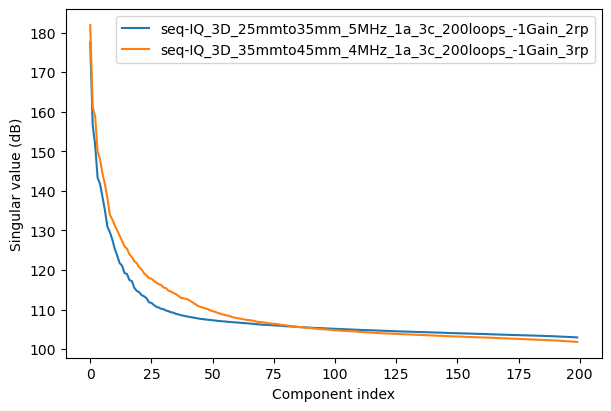

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout="constrained")
for i, sequence in enumerate(sequences):
    ax.plot(20 * np.log10(S[sequence]), label=sequence)
ax.legend()
ax.set_xlabel("Component index")
ax.set_ylabel("Singular value (dB)")

Text(0, 0.5, 'Singular value (dB)')

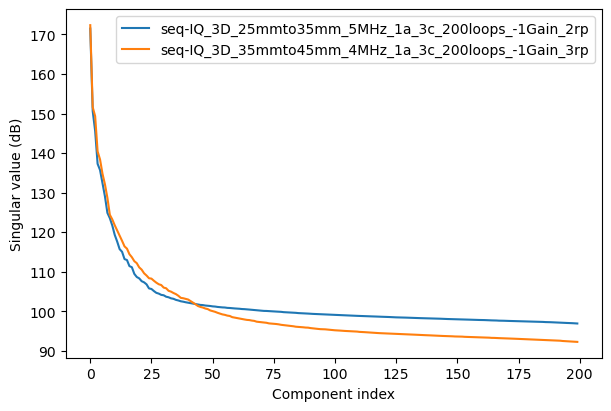

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout="constrained")
ax.plot(20 * np.log10(S[sequences[0]] / 2), label=sequences[0])
ax.plot(20 * np.log10(S[sequences[1]] / 3), label=sequences[1])
ax.legend()
ax.set_xlabel("Component index")
ax.set_ylabel("Singular value (dB)")